In [1]:
import numpy as np
import glob
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from oaatutils import *

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
f='../postp/oaat_postp.nc'
ds=xr.open_dataset(f)

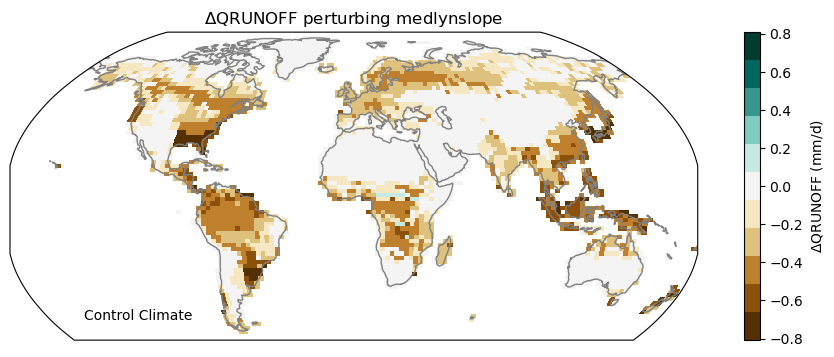

In [6]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(111,projection=ccrs.Robinson()) # first row, first col
extent = [-180, 180,-60,90]
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.coastlines(color='grey')

cmap=brown_green()
p='medlynslope'
x=24*60*60*ds.QRUNOFF_gridded_mean.sel(exp='CTL2010',param=p)
dx=x.sel(minmax='max')-x.sel(minmax='min')
get_map(dx).plot(cmap=cmap,transform=ccrs.PlateCarree(),
                 cbar_kwargs={'label':'$\Delta$QRUNOFF (mm/d)'})
ax.text(-160,-50,'Control Climate',transform=ccrs.PlateCarree())
plt.title('$\Delta$QRUNOFF perturbing '+p);
plt.savefig('../figs/QRUNOFFabs_x_medlynslope_CTL2010.png',dpi=300,bbox_inches='tight')